# 6章 ルーティングプロトコル

前章では、インターネットにおけるパケット転送の中核を担うルータについて学習しました。
ただ、非常に多くのノードが参加するインターネットで、パケットの転送先を決めるルーティングテーブルをすべて手打ちで設定するのは非現実的です。
本章では、ルーティングテーブルを設定するためのプロトコルとアルゴリズムについて学習します。

## ルーティングプロトコルとは

### ルーティングプロトコルの意義

ルーティングプロトコルの基本的な考え方は、ルータ間でメッセージを交換し、それに基づいて自動でルート設定を行うことです。
このプロセスにより、膨大な数のIPアドレスを人間が管理することなく、機械的に最適な経路でパケットを転送できます。
また自動化することによって、ノードの追加や故障などを含めたネットワークの動的な変化に柔軟に対応し、管理の複雑さを軽減できます。

### ルーティングプロトコルの動作原理
ルーティングプロトコルは、ネットワーク上のルータが互いに情報を交換し合うことで、パケットの転送経路を決定します。
各ルータは、隣接するルータからの情報を受け取り、自身のルーティングテーブルを更新していきます。
静的ルーティングでは、ネットワーク管理者が手動でルーティングテーブルに経路を設定します。
この方法は、ネットワークの規模が小さく、変更がほとんどない場合にはシンプルで効率的です。
しかし、ネットワークの拡大や、リンクの障害などの変更が頻繁に発生する環境では、管理者が全ての変更に手動で対応することは非効率で、時には不可能になります。

ルーティングプロトコルを使用すると、ネットワークトポロジや状態が自動で共有され、各ルータにおいてルーティングテーブルが更新されます。
またリンク障害が発生した場合にも、迅速に代替経路を見つけ出し、通信の中断を最小限に抑えます。

### プロトコルの種類

ルーティングプロトコルは、大きく内部プロトコル（Interior Gateway Protocols, IGPs）と外部プロトコル（Exterior Gateway Protocols, EGPs）の二つに分類されます。
これらは、ネットワークの運用規模や範囲に応じて使用され、異なる目的と機能を持っています。
代表的な内部プロトコルとしてはOSPFが、外部プロトコルとしてはBGPが挙げられます。
以下に、内部プロトコルと外部プロトコルの違い、およびOSPFとBGPの特徴について解説します。

#### 内部プロトコル（IGPs）
内部プロトコルは、同一の管理下にあるネットワーク内で使用されるルーティングプロトコルです。
これらは、主に自律システム（AS）内のルータ間でルーティング情報を交換し、内部のネットワークトラフィックを効率的に管理するために設計されています。
IGPsは、ネットワークのトポロジー変更に迅速に対応し、内部のデータ転送経路を最適化することを目的としています。

OSPF（Open Shortest Path First）は、最も広く使用される内部ルーティングプロトコルの一つで、リンクステートプロトコルに属します。
OSPFは、ネットワークの全ルータがトポロジー情報を共有し、各ルータが独自に最短経路を計算することにより、効率的なルーティングを実現します。
階層的なデザインが可能で、大規模なネットワークでもスケーラビリティを保ちながら運用できます。

#### 外部プロトコル（EGPs）
外部プロトコルは、異なる自律システム間でルーティング情報を交換するために使用されるプロトコルです。
インターネットは複数の自律システムで構成されており、EGPsはこれら異なる管理下にあるネットワーク同士が通信するためのルーティングポリシーを確立します。
EGPsの主な目的は、異なるAS間でのデータ伝送経路を決定し、インターネット全体の接続性を維持することです。

BGP（Border Gateway Protocol）は、インターネットのバックボーンとなる外部ルーティングプロトコルであり、経路ベクトルプロトコルに分類されます。
BGPは、異なる自律システム間のルーティング情報を交換し、インターネット全体のデータ転送経路を決定します。
ポリシーベースのルーティングが特徴で、各ASは独自のポリシーに基づいてトラフィックの流れを制御することができます。
これにより、組織はトラフィックの経路や提供者間での接続性を細かく管理できます。

ここでは、基本的かつ有名なプロトコルであるOSPFを実装しながら、ルーティングプロトコルについて学習していきます。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 272 (delta 42), reused 39 (delta 21), pack-reused 212
Receiving objects: 100% (272/272), 105.53 KiB | 11.73 MiB/s, done.
Resolving deltas: 100% (190/190), done.


## OSPF

### 隣接関係の確立とHelloパケット

OSPFの最もベーシックな動作は、ルータ同士の隣接関係の確立です。
Helloパケットは、OSPFネットワーク内のルータ間で隣接関係を確立し、維持するための基本的なメカニズムです。
このHelloパケットの交換は、ルータがネットワーク内の他のルータの存在を検出し、隣接ルータとの通信を確立するために不可欠です。

### Helloパケットの役割
OSPFでは、ルータはまずHelloパケットを送信して周囲のルータを検出します。
受信したルータは、Helloパケットに応答して自身の存在を知らせます。
このプロセスを通じて、ルータ間で隣接関係が確立されます。
また、Helloパケットは定期的に交換されるため、ルータ間の接続状態が常に最新の状態に保たれます。
リンク障害やルータの故障が発生した場合には、迅速にネットワークトポロジの変更が検出されることになります。

### `HelloPacket`クラスの実装

`HelloPacket`クラスは、OSPFプロトコルで使用されるHelloパケットを表します。
このパケットは、ルータが自分の存在を周囲に知らせたり、隣接するルータとの接続を確認したりするために使用されます。

#### コンストラクタ（`__init__`メソッド）

`__init__`メソッドは、クラスのインスタンスが作成される際に自動的に呼び出される特別なメソッドです。
このメソッドは、Helloパケットを初期化するために必要な情報を引数として受け取ります。

- `source_mac`と`source_ip`は、パケットを送信するルーターのMACアドレスとIPアドレスを指定します。
- `destination_mac`と`destination_ip`は、パケットの宛先を指定します。Helloパケットはブロードキャストされるため、宛先MACアドレスは`FF:FF:FF:FF:FF:FF`、宛先IPアドレスは`224.0.0.5`となります。
- `ttl`（Time To Live）は、パケットがネットワーク内で生存できる期間を指定します。Helloパケットの場合、この値は`1`です。
- `header_size`と`payload_size`は、パケットのヘッダとペイロードのサイズをバイト単位で指定します。

#### ペイロードの設定

Helloパケットのペイロードには、ネットワークの構成やルータ間の関係に関する情報が含まれます。

- `network_mask`は、ルータが接続されているネットワークのサブネットマスクを指定します。
- `router_id`は、パケットを送信するルータのIDを指定します。
- `hello_interval`は、Helloパケットを送信する間隔を秒単位で指定します。
- `neighbors`は、隣接するルータのリストを含みます。この情報を用いて自身の隣接ルータを認識し、ネットワークのトポロジを構築します。

#### 文字列表現の定義（`__str__`メソッド）

`__str__`メソッドは、クラスのインスタンスを文字列として表現する際に使用されます。このメソッドは、Helloパケットの重要な情報を読みやすい形式で返します。


In [ ]:
from sec6a.Packet import Packet

# Packetクラスから継承したHelloPacketクラスの定義
class HelloPacket(Packet):
    def __init__(self, source_mac, source_ip, network_mask, router_id, hello_interval, neighbors, network_event_scheduler):
        # 親クラスのコンストラクタを呼び出し、共通のパケット情報を設定する。
        super().__init__(
            source_mac=source_mac,  # 送信元のMACアドレス
            destination_mac="FF:FF:FF:FF:FF:FF",  # OSPF Helloパケットはブロードキャストアドレスに送信される
            source_ip=source_ip,  # 送信元のIPアドレス
            destination_ip="224.0.0.5",  # OSPFで使用されるマルチキャストアドレス。Helloパケットの標準的な宛先IP
            ttl=1,  # OSPF HelloパケットのTTLは1。直接接続された隣接ルータにのみ到達する。
            fragment_flags={},  # フラグメントのフラグ（ここでは使用しない）
            fragment_offset=0,  # フラグメントのオフセット（ここでは使用しない）
            header_size=24,  # OSPF Helloパケットのヘッダサイズをバイト単位で指定
            payload_size=20,  # OSPF Helloパケットのペイロードサイズをバイト単位で指定
            network_event_scheduler=network_event_scheduler  # ネットワークイベントスケジューラのインスタンス
        )
        # Helloパケット固有のペイロード情報を設定
        self.payload = {
            "network_mask": network_mask,  # ネットワークマスク
            "router_id": router_id,  # ルータのID
            "hello_interval": hello_interval,  # Helloパケットを送信する間隔（秒）
            "neighbors": neighbors  # 隣接しているルータのリスト
        }

    # Helloパケットの主要な情報を人が読める形式で返す特殊メソッド
    def __str__(self):
        return f'HelloPacket(送信元MAC: {self.header["source_mac"]}, 宛先MAC: {self.header["destination_mac"]}, 送信元IP: {self.header["source_ip"]}, ネットワークマスク: {self.payload["network_mask"]}, ルータID: {self.payload["router_id"]}, Helloインターバル: {self.payload["hello_interval"]}, 隣接ルータ: {self.payload["neighbors"]})'


### `Router`クラスのアップデート


```
class Router:
    def __init__(self, node_id, ip_addresses, network_event_scheduler, hello_interval=10, lsa_interval=10, default_route = None):
        # Helloに関連するもの以外は省略
        self.interfaces = {}  # 各インターフェースに割り当てられたIPアドレスを格納する辞書
        self.routing_table = {}  # 目的地IPアドレスへの最適な経路を格納するルーティングテーブル
        self.neighbors = {}  # 隣接ルータの状態（IDとその他の情報）を格納する辞書
        self.hello_interval = hello_interval  # Helloパケットを送信する間隔（秒）
        self.schedule_hello_packet()  # Helloパケットの送信スケジュールを設定
```


#### Helloパケットのスケジューリングと送信
- schedule_hello_packet関数：この関数は、ルータが起動した際に最初のHelloパケットの送信をスケジュールします。送信の遅延はランダムに0から0.1秒の間で設定され、これにより、同時に多数のルータが起動しても全てのHelloパケットが同時にネットワーク上に流れることを防ぎます。この初期遅延の後、send_hello_packet関数が呼び出されます。

```
    def schedule_hello_packet(self):
        # 最初のHelloパケット送信をスケジュールする関数
        initial_delay = random.uniform(0, 0.1)  # 最初の送信遅延をランダムに設定（0～0.1秒）
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time + initial_delay,  # 現在時刻に遅延を加えた時刻に設定
            self.send_hello_packet  # Helloパケットを送信する関数をスケジュール
        )
```

- send_hello_packet関数：ルータはこの関数を通じて、自身が持つ全てのインターフェースにHelloパケットを送信します。各Helloパケットには、送信元のMACアドレス（ここではダミーのアドレスが使用されています）、送信元のIPアドレス、サブネットマスク、ルータID、Helloインターバル、そして現在認識している隣接ルータのIDリストが含まれています。これにより、他のルータは自身の隣接ルータとしてこのルータを認識し、ルーティング情報の交換が可能になります。また、この関数は自身を再帰的にスケジュールし、定期的にHelloパケットを送信し続けます。

```
    def send_hello_packet(self):
        # Helloパケットを送信する関数
        for link, interface_cidr in self.interfaces.items():  # 登録された全インターフェースに対してループ
            network_address, mask_length = interface_cidr.split('/')  # CIDR表記からネットワークアドレスとマスク長を取得
            hello_packet = HelloPacket(
                source_mac="00:00:00:00:00:00",  # 送信元のMACアドレス（ここではダミー）
                source_ip=network_address,  # 送信元のIPアドレス
                network_mask=self.cidr_to_subnet_mask(mask_length),  # CIDRマスクをサブネットマスクに変換
                router_id=self.node_id,  # ルータのID
                hello_interval=self.hello_interval,  # Helloインターバル
                neighbors=list(self.neighbors.keys()),  # 現在認識している隣接ルータのIDリスト
                network_event_scheduler=self.network_event_scheduler  # ネットワークイベントスケジューラ
            )
            link.enqueue_packet(hello_packet, self)  # パケットを送信キューに追加

        # Helloパケットの定期的な送信をスケジュール
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time + self.hello_interval,  # 次のHelloパケット送信時刻
            self.send_hello_packet  # Helloパケットを送信する関数を再スケジュール
        )
```

#### 受信したパケットの転送処理
- forward_packet関数：この関数は、ルータがパケットを受信した際に呼び出され、受信したパケットの宛先に基づいて適切な転送処理を行います。まず、パケットの宛先IPアドレスを確認し、それがOSPFのマルチキャストアドレス（224.0.0.5）である場合は、全インタフェースを通じてそのパケットを転送します。これは、HelloパケットなどのOSPF制御パケットをネットワーク内の全ルータに広めるために使用されます。一方、特定の宛先へのユニキャストパケットの場合、ルーティングテーブルを参照して最適な転送ルートを選択し、パケットを転送します。適切な転送ルートが見つからない場合は、設定されているデフォルトルートを使用するか、パケットを破棄します。

```
    def forward_packet(self, packet):
        # 受信したパケットの転送処理を行う関数
        destination_ip = packet.header["destination_ip"]  # パケットの宛先IPアドレス
        next_hop, link = self.get_route(destination_ip)  # 宛先への最適な経路（ネクストホップと使用するリンク）を取得

        if destination_ip == "224.0.0.5":  # 宛先がOSPFのマルチキャストアドレスの場合
            for link in self.interfaces.keys():  # 全インターフェースにパケットを転送
                self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
                link.enqueue_packet(packet, self)
        elif link:  # 宛先への直接のリンクが存在する場合（ユニキャスト）
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
            link.enqueue_packet(packet, self)
        elif self.default_route:  # デフォルトルートが設定されている場合
            self.network_event_scheduler.log_packet_info(packet, "forwarded via default route", self.node_id)
            self.default_route.enqueue_packet(packet, self)
        else:  # 転送ルートが見つからない場合
            self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)  # パケットを破棄
```

- receive_packet関数：まず受信したパケットがHelloパケットかどうかを判断します。これは、isinstance関数を使用して、パケットがHelloPacketクラスのインスタンスかどうかをチェックすることで行われます。受信したパケットがHelloパケットでない場合、まずパケットヘッダのTTL(Time To Live)フィールドがデクリメントされます。TTLが0以下になった場合、パケットはTTLが切れたとみなされ、破棄されます。
TTLがまだ有効な場合、パケットの宛先IPアドレスがこのルータのサブネット内の宛先かどうかを判断します。ルータは、自身のインターフェースと宛先IPを比較し、宛先が自身のサブネット内にあるかどうかを確認します。パケットが最終宛先に到達していない場合は、forward_packet関数を使用して適切な次のステップに転送します。

```
    def receive_packet(self, packet, received_link):
        # 受信したパケットがHelloパケットかどうかを判定
        if isinstance(packet, HelloPacket):
            # Helloパケットの場合、専用の処理関数を呼び出し
            self.receive_hello_packet(packet, received_link)
            return  # Helloパケットの処理後、この関数から抜ける

        # 通常のパケットの場合、Time To Live (TTL) をデクリメント（1減らす）
        packet.header["ttl"] -= 1

        # TTLが0以下になった場合、パケットは破棄される
        if packet.header["ttl"] <= 0:
            self.network_event_scheduler.log_packet_info(packet, "dropped due to TTL expired", self.node_id)
            return
        else:
            destination_ip = packet.header["destination_ip"]
            # 宛先IPがCIDR形式であれば、IPアドレス部分のみを取得
            if '/' in destination_ip:
                destination_ip, _ = destination_ip.split('/')
            # 登録された全インターフェースに対してループ
            for link, interface_cidr in self.interfaces.items():
                network_address, mask_length = interface_cidr.split('/')
                subnet_mask = self.cidr_to_subnet_mask(mask_length)
                # 宛先IPがこのルータのサブネットに属するかどうかをチェック
                if self.matches_subnet(destination_ip, network_address, subnet_mask):
                    # パケットが最終宛先に到達したかどうかを判定
                    if self.is_final_destination(packet, network_address):
                        pass  # 最終宛先の場合、特別な処理はここに記述（この例では省略）
                    else:
                        # 最終宛先でない場合、パケットを転送
                        self.forward_packet(packet)
                    return
            # マッチするサブネットが見つからなかった場合、パケットを転送
            self.forward_packet(packet)
```

- receive_hello_packet関数：Helloパケットの場合、この関数が呼び出され、Helloパケットの処理が行われます。この関数は、Helloパケットから送信ルータのIDを抽出し、既知の隣接ルータかどうかを確認します。新しい隣接ルータである場合、または既存の隣接ルータの情報が更新される場合、隣接ルータの情報が更新され、変更があったことが記録されます。

```
    def receive_hello_packet(self, packet, received_link):
        # Helloパケットから送信ルータのIDを取得
        router_id = packet.payload["router_id"]
        new_neighbor = False  # 新しい隣接ルータかどうかを判定するフラグ
        now = self.network_event_scheduler.current_time

        # 受信したHelloパケットの送信元が既知の隣接ルータかどうかをチェック
        if router_id not in self.neighbors:
            # 未知の隣接ルータの場合、新しい隣接情報を追加
            new_neighbor = True
            self.neighbors[router_id] = {
                "last_hello_time": now,  # 最後にHelloを受信した時刻
                "link": received_link,  # Helloパケットを受信したリンク
                "neighbor_info": packet.payload  # 隣接ルータの詳細情報
            }
        else:
            # 既知の隣接ルータの情報を更新
            last_hello_time = self.neighbors[router_id]["last_hello_time"]
            if now > last_hello_time:
                self.neighbors[router_id]["last_hello_time"] = now
            if received_link != self.neighbors[router_id]["link"]:
                new_neighbor = True
                self.neighbors[router_id]["link"] = received_link
            if packet.payload != self.neighbors[router_id]["neighbor_info"]:
                new_neighbor = True
                self.neighbors[router_id]["neighbor_info"] = packet.payload

        # 新しい隣接情報が追加または更新された場合、隣接ルータの情報を表示
        if self.network_event_scheduler.routing_verbose:
            if new_neighbor:
                self.print_neighbor_info(now)
            else:
                print(f"{now} Helloパケットを受信しましたが、隣接ルータの情報は更新されていません（ルータ {self.node_id}）")
```

#### その他のメソッド
隣接するルータやリンクの情報を得るメソッドを準備しておきます。

```
    def get_neighbor_router_id(self, link, current_router_id):
        # 特定のリンクを介して接続されている隣接ルータのIDを取得
        if link.node_x.node_id == current_router_id:
            return link.node_y.node_id  # 現在のルータがnode_xの場合、node_yのIDを返す
        elif link.node_y.node_id == current_router_id:
            return link.node_x.node_id  # 現在のルータがnode_yの場合、node_xのIDを返す
        else:
            return None  # リンクが現在のルータと接続していない場合はNoneを返す

    def get_link_to_neighbor(self, neighbor_router_id):
        # 指定された隣接ルータIDに接続するリンクを取得
        if neighbor_router_id is None:
            # next_hopがNoneの場合、直接接続されたリンクを探索
            for link in self.links:
                if link.node_x.node_id == self.node_id or link.node_y.node_id == self.node_id:
                    return link  # 直接接続されたリンクを返す
            return None  # 直接接続されたリンクが見つからない場合

        # next_hopが指定された隣接ルータの場合、対応するリンクを検索
        if neighbor_router_id in self.neighbors:
            return self.neighbors[neighbor_router_id]['link']  # 隣接ルータへのリンクを返す

        # 上記の条件に当てはまらない場合、全リンクを探索して対応するリンクを探す
        for link in self.links:
            if link.node_x.node_id == neighbor_router_id or link.node_y.node_id == neighbor_router_id:
                return link  # 指定された隣接ルータに接続するリンクを返す

        return None  # 条件に合致するリンクが見つからない場合
```


### 隣接関係構築のテスト

`Hello`パケットによる隣接関係構築のテストを行ってみましょう。
`network_event_scheduler`クラスのインスタンス生成時に、`routing_verbose=True`に設定することで、ルーティング関連情報を出力して確認できます。
以下の例では4つのルータを接続しています。

`Hello`の受信時にログを出力するように設定されているため、まずは実行して確認してみます。
ログは以下のような形式になっています。
```
10.07996383775451 Helloパケット受信によるアップデート（ルータ r4）:
  ルータID: r2
    最後のHello受信時刻: 10.057580038332098
    隣接ルータへのリンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r2', 'hello_interval': 10, 'neighbors': ['r4', 'r3']}
  ルータID: r1
    最後のHello受信時刻: 10.07996383775451
    隣接ルータへのリンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r1', 'hello_interval': 10, 'neighbors': ['r4', 'r3']}
10.094094578178272 Helloパケットを受信しましたが、隣接ルータの情報は更新されていません（ルータ r1）
```

- 隣接ルータ情報の更新: ルータは受信したHelloパケットに基づいて隣接ルータ情報を更新します。これには、最後のHello受信時刻の更新、隣接ルータへのリンク情報の更新、および隣接ルータリストの更新が含まれます。隣接ルータの情報が新しくない場合、つまり以前に受信した情報と変わらない場合は、「隣接ルータの情報は更新されていません」と記録されます。

- ログの形式: 各ログエントリは、Helloパケットの受信イベントを示しており、受信時刻、アクションの説明（例: "Helloパケット受信によるアップデート"）、対象ルータのID、送信ルータのID、最後のHello受信時刻、隣接ルータへのリンク情報、および受信したHelloパケットに含まれる追加情報を含んでいます。

- 隣接ルータへのリンク: ログに記載されている隣接ルータへのリンク情報には、リンクの両端を示すルータID、帯域幅、遅延、パケットロス率が含まれます。これらの情報は、ルータが隣接ルータと通信する際のリンクの品質を反映しています。

- 追加情報: 受信したHelloパケットに含まれる追加情報には、ネットワークマスク、送信ルータのID、Helloインターバル、および隣接ルータのリストが含まれます。Helloインターバルは、次のHelloパケットが送信されるまでの時間を示し、隣接ルータのリストは、送信ルータが現在認識している隣接ルータのIDを示します。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


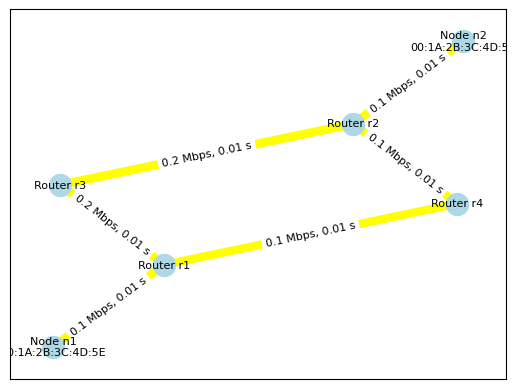

インタフェース情報（ルータ r1）:
  リンク: リンク(n1 ↔ r1, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 192.168.1.254/24
  リンク: リンク(r1 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.3.1/24
  リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.4.1/24
インタフェース情報（ルータ r2）:
  リンク: リンク(r2 ↔ n2, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 192.168.2.254/24
  リンク: リンク(r2 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.3.1/24
  リンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.4.1/24
インタフェース情報（ルータ r3）:
  リンク: リンク(r1 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.3.2/24
  リンク: リンク(r2 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.3.2/24
インタフェース情報（ルータ r4）:
  リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.4.2/24
  リンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.4.2/24
0.03552361571324298 Helloパケット受信によるアップデート（ルータ r3）:
  ルータID: r2
    最後のHello受信時刻: 0.03552361571324298
    隣接ルータへのリンク: リンク(r2 ↔ r3, 帯域幅: 

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec6a.NetworkEventScheduler import NetworkEventScheduler
from sec6a.Node import Node
from sec6a.Router import Router
from sec6a.Link import Link

# routing_verbose=Trueでルーティング関連情報を出力
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.1/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.3.1/24", "10.1.4.1/24"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.2.3.1/24", "10.2.4.1/24"], network_event_scheduler=network_event_scheduler)
router3 = Router(node_id="r3", ip_addresses=["10.1.3.2/24", "10.2.3.2/24"], network_event_scheduler=network_event_scheduler)
router4 = Router(node_id="r4", ip_addresses=["10.1.4.2/24", "10.2.4.2/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router2, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router1, router3, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(router1, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(router2, router3, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(router2, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 各ルータのインタフェース情報を確認
router1.print_interfaces()
router2.print_interfaces()
router3.print_interfaces()
router4.print_interfaces()

# イベントスケジューラを実行
network_event_scheduler.run_until(20.0)

# 結果を確認
#network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


## LSA

OSPFの重要なポイントの一つがLSA（Link-State Advertisement）です。
LSAは、ネットワークのトポロジと状態を表す情報を含むパケットであり、OSPFを使用するルータ間で交換されます。

### LSAの概要

LSAは、ルータが直接接続しているリンクの状態（例えば、リンクのアップ/ダウン状態、コストなど）を含む情報をネットワーク内の他のルータに伝えるために使用されます。
各ルータは受信したLSAを自身のリンクステートデータベースに保存し、さらに隣接ルータに転送します。
このプロセスを通じて、全ルータがネットワークの一貫したビューを持つことができます。
すなわち各ルータは、受信したLSAを基にネットワークの全体像を構築し、ルーティングアルゴリズム（例えば、後述するダイクストラアルゴリズム）を使用してルーティングテーブルを計算します。
ネットワーク内のリンクが変更された場合（例えば、新しいリンクの追加、既存リンクのコスト変更、リンク障害など）、その変更は新しいLSAを通じて迅速に全ネットワークに配布され、各ルータはルーティングテーブルを更新します。

### `LSAPacket` クラス

- **クラスの継承**: `LSAPacket`クラスは`Packet`クラスを継承しており、一般的なパケットの属性を引き継ぎつつ、LSAパケット固有の情報を追加しています。

- **コンストラクタ `__init__`**: このメソッドは、LSAパケットを初期化するために呼び出されます。LSAパケット固有の情報として、`router_id`（送信ルータのID）、`sequence_number`（シーケンス番号）、`link_state_info`（リンク状態情報）が引数として与えられます。

    - **source_mac**: 送信元のMACアドレス。
    - **destination_mac**: 通常、LSAパケットはブロードキャストされるため、宛先MACアドレスは`FF:FF:FF:FF:FF:FF`に設定されます。
    - **source_ip**: 送信元のIPアドレス。
    - **destination_ip**: OSPFのマルチキャストアドレス`224.0.0.5`に設定され、これによりパケットはOSPFをサポートする全てのルータに送信されます。
    - **ttl**: OSPFパケットのTTL（Time To Live）は通常1に設定され、パケットは直接接続された隣接ルータにのみ送信されます。
    - **header_size**と**payload_size**: ヘッダサイズとペイロードサイズは、実際のトポロジ情報に基づいて適切に設定されます。

- **ペイロード**: LSAパケット特有の情報は、ペイロード部分に格納されます。これには、`router_id`、`sequence_number`、`link_state_info`が含まれ、これらの情報により、ネットワーク内の他のルータがトポロジの変更を追跡できるようになります。

- **`__str__` メソッド**: このメソッドは、パケットの情報を文字列形式で返します。これにより、デバッグやログ出力時にパケットの内容を確認できます。


In [ ]:
from sec6b.Packet import Packet

# Packetクラスを継承するLSAPacketクラスを定義
class LSAPacket(Packet):
    # LSAPacketのコンストラクタ
    def __init__(self, source_mac, source_ip, router_id, sequence_number, link_state_info, network_event_scheduler):
        # 親クラス（Packet）のコンストラクタを呼び出し、共通属性を初期化
        super().__init__(
            source_mac=source_mac,  # 送信元MACアドレス
            destination_mac="FF:FF:FF:FF:FF:FF",  # LSAパケットはブロードキャストされるため、宛先MACアドレスはブロードキャストアドレス
            source_ip=source_ip,  # 送信元IPアドレス
            destination_ip="224.0.0.5",  # OSPFのマルチキャストアドレス。OSPFを使用する全ルータへの送信を意味する
            ttl=1,  # OSPFパケットのTTLは通常1。直接接続された隣接ルータにのみ送信される
            fragment_flags={},  # フラグメントフラグ（この例では使用しない）
            fragment_offset=0,  # フラグメントオフセット（この例では使用しない）
            header_size=24,  # パケットヘッダのサイズ。実際の値に基づいて調整する必要がある
            payload_size=100,  # ペイロードのサイズ。トポロジ情報の大きさに基づいて調整する必要がある
            network_event_scheduler=network_event_scheduler  # ネットワークイベントスケジューラ。イベント管理に使用
        )
        # ペイロードにLSA特有の情報を格納
        self.payload = {
            "router_id": router_id,  # このLSAパケットを送信するルータのID
            "sequence_number": sequence_number,  # シーケンス番号。パケットの一意性と新鮮さを保証
            "link_state_info": link_state_info  # リンク状態情報。ネットワークトポロジの詳細
        }

    # LSAPacketオブジェクトを文字列表現で返す特殊メソッド
    def __str__(self):
        # 送信元MAC、送信元IP、トポロジ情報を含む文字列を返す
        return f'LSAPacket(送信元MAC: {self.header["source_mac"]}, 送信元IP: {self.header["source_ip"]}, トポロジ情報: {self.payload["link_state_info"]})'


### リンクステートの共有

ネットワーク内の各ルータは、自身が直接接続しているリンクの状態（例: リンクのコスト、リンクがアクティブかどうかなど）を定期的にLSAとしてパッケージングします。このLSAには、送信ルータのID、シーケンス番号（このLSAが何番目に生成されたかを示す一意の番号）、およびリンク状態情報が含まれます。生成されたLSAは、ネットワーク内の他のすべてのルータにブロードキャストまたはマルチキャストされます。

LSAを受信したルータは、ネットワーク内の他のルータに再送信します。その結果として、ネットワーク内の全ルータが最終的に同じリンクステート情報を共有することになります。ルータは、既に知っている（古いシーケンス番号の）LSAは無視し、新しい情報のみを他のルータにフラッディングします。

### トポロジデータベースの更新

受信したLSAを基に、各ルータはネットワークのトポロジデータベースを構築します。トポロジデータベースには、ネットワーク内の全ルータとリンク、それらのリンクのコスト、リンクの状態などの情報が含まれます。このデータベースは、全ルータ間で一貫性が保たれるように設計されています。

新しいLSA（より新しいシーケンス番号を持つLSA）を受信すると、ルータはトポロジデータベースを更新します。この更新プロセスにより、ネットワーク内で発生した変更（新しいリンクの追加、リンクのコスト変更、リンクの障害など）が迅速に反映されます。

トポロジデータベースの更新後、ルータはこのデータベースを使用してルーティングテーブルを再計算します。最短経路アルゴリズム（通常はダイクストラアルゴリズム）が使用され、各宛先への最適なパスが決定されます。

### `Router`クラスのアップデート

```
class Router:
    def __init__(self, node_id, ip_addresses, network_event_scheduler, hello_interval=10, lsa_interval=10, default_route = None):
        # Helloに関連するもの以外は省略
        self.lsa_sequence_number = 0  # LSAパケットのシーケンス番号を0で初期化
        self.lsa_interval = lsa_interval  # LSAパケット送信間隔の設定
        self.lsa_database = {}  # ルータが受信したLSA情報を格納するデータベース
        self.is_topology_initialized = False  # トポロジデータベースが初期化されているかどうかのフラグ
        self.topology_database = {}  # ネットワークのトポロジ情報を格納するデータベース
        self.schedule_lsa()  # LSA送信のスケジューリングを行う
```

#### LSAのスケジューリングと送信
- `schedule_lsa`メソッドでは、LSAパケットの最初の送信をランダムな遅延後にスケジュールします。ネットワークが起動する際にすべてのルータから同時にLSAパケットが送信されることを避け、ネットワークの混雑を防ぎます。

```
    def schedule_lsa(self):
        # LSAパケットの送信をスケジュールする関数
        initial_delay = random.uniform(0.3, 0.5)  # 初回のLSA送信遅延をランダムに設定
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time + initial_delay,
            self.send_lsa
        )
```

- `send_lsa`メソッドでは、ルータが自身のトポロジ情報（どのルータやネットワークセグメントに接続しているかなど）を含むLSAパケットを作成し、ネットワーク上の全てのルータに送信します。

```
    def send_lsa(self):
        # LSAパケットを送信する関数
        seq_number = self.increment_lsa_sequence_number()  # シーケンス番号をインクリメント
        link_state_info = self.get_link_state_info()  # リンク状態情報を取得

        # ネットワークの各リンクに対してLSAパケットを送信
        for link, ip_address in self.interfaces.items():
            lsa_packet = LSAPacket(
                source_mac="00:00:00:00:00:00",  # 送信元MACアドレス（ダミー）
                source_ip=ip_address,  # 送信元IPアドレス
                router_id=self.node_id,  # ルータID
                sequence_number=seq_number,  # シーケンス番号
                link_state_info=link_state_info,  # リンク状態情報
                network_event_scheduler=self.network_event_scheduler  # ネットワークイベントスケジューラ
            )
            link.enqueue_packet(lsa_packet, self)  # パケットを送信キューに追加

        # 次のLSA送信をスケジュール
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time + self.lsa_interval,
            self.send_lsa
        )

    def increment_lsa_sequence_number(self):
        # LSAシーケンス番号をインクリメントする関数
        self.lsa_sequence_number += 1
        return self.lsa_sequence_number
```

- `flood_lsa`メソッドでは、受信したLSAパケットを他のルータに転送（フラッド）します。

```
    def flood_lsa(self, original_lsa_packet):
        # 受信したLSAパケットをネットワーク内の他のルータにフラッドする関数
        original_sender_id = original_lsa_packet.payload["router_id"]  # 元の送信ルータIDを取得

        # 各リンクをループし、元の送信ルータ以外にLSAパケットを送信
        for link, ip_address in self.interfaces.items():
            if link.node_x.node_id != original_sender_id and link.node_y.node_id != original_sender_id:
                lsa_packet = original_lsa_packet  # 元のLSAパケットをそのまま使用
                link.enqueue_packet(lsa_packet, self)  # パケットを送信キューに追加
```

#### LSAの受信とトポロジデータベースの更新
- `receive_lsa`メソッドでは、他のルータから送信されてきたLSAパケットを受信し、その内容を処理します。受信したLSAの情報が新しい場合（シーケンス番号が大きい場合）、ルータは自身のトポロジデータベースを更新し、必要に応じてルーティングテーブルを再計算します。

```
    def receive_lsa(self, lsa_packet):
        # LSAパケットを受信した際の処理を行う関数
        lsa_info = lsa_packet.payload["link_state_info"]  # 受信したLSA情報を取得
        now = self.network_event_scheduler.current_time

        if not self.is_topology_initialized:
            self.initialize_topology_database()  # トポロジデータベースを初期化
            self.is_topology_initialized = True

        if "sequence_number" in lsa_packet.payload:
            seq_number = lsa_packet.payload["sequence_number"]
            current_lsa_info = self.topology_database.get(lsa_packet.payload["router_id"], {})

            # 受信したLSAが新しい情報を持っている場合、トポロジデータベースを更新
            if seq_number > current_lsa_info.get("sequence_number", -1):
                self.topology_database[lsa_packet.payload["router_id"]] = {
                    "sequence_number": seq_number,
                    "link_state_info": lsa_info
                }

                if self.network_event_scheduler.routing_verbose:
                    self.print_topology_database(now)

                # ここでルーティングテーブルの再計算処理を実行する

                # 更新されたLSAを隣接ルータにフラッド
                self.flood_lsa(lsa_packet)
            else:
                # シーケンス番号が古い、または同じLSAは無視
                if self.network_event_scheduler.routing_verbose:
                    print(f"{now} 古いLSAを受信しました（ルータ {self.node_id}）")
```

- `initialize_topology_database`メソッドでは、ルータ自身のトポロジ情報をデータベースに登録します。これは、ルータがネットワークに参加した直後に行われます。

```
    def initialize_topology_database(self):
        # トポロジデータベースを初期化する関数
        link_state_info = {}
        for link, ip_address in self.interfaces.items():
            link_state_info[link] = {
                "ip_address": ip_address,  # インターフェースのIPアドレス
                "cost": self.calculate_link_cost(link),  # リンクコスト
                "state": "active"  # 初期状態はアクティブ
            }

        # 自身のルータ情報をトポロジデータベースに登録
        self.topology_database = {
            self.node_id: {'link_state_info': link_state_info}
        }
```

### LSAのテスト

`LSA`パケットによるトポロジデータベース構築のテストを行ってみましょう。
先ほどと同様のトポロジにおいて、LSAの機能を追加したコードでシミュレーションを実行してみます。
`network_event_scheduler`クラスのインスタンス生成時に、`routing_verbose=True`に設定することで、ルーティング関連情報を出力して確認できます。
`LSA`の受信時にログを出力するように設定されているため、まずは実行して確認してみます。
ログは以下のような形式になっています。

```
0.3372472787445949 トポロジデータベース（ルータ r1）:
  ルータID: r1
    リンク: リンク(n1 ↔ r1, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
      IPアドレス: 192.168.1.254/24
      コスト: 1e-05
      状態: active
    リンク: リンク(r1 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
      IPアドレス: 10.1.3.1/24
      コスト: 5e-06
      状態: active
    リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
      IPアドレス: 10.1.4.1/24
      コスト: 1e-05
      状態: active
  ルータID: r4
    リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
      IPアドレス: 10.1.4.2/24
      コスト: 1e-05
      状態: active
    リンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
      IPアドレス: 10.2.4.2/24
      コスト: 1e-05
      状態: active
```

この例は、シミュレーション開始直後のルータr1のトポロジデータベースの内容を示しています。

- タイムスタンプ: 0.3372472787445949は、ログが記録された時刻を示しています。これは、シミュレーション開始からの経過時間（秒単位）です。

- ルータID: ここではr1とr4が示されています。これは、トポロジデータベースに記録されているリンク情報が、どのルータに関連しているかを示しています。

- リンク情報: 各ルータIDの下には、そのルータに関連するリンクの詳細が列挙されています。例えば、リンク(n1 ↔ r1, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)は、ノードn1とルータr1を結ぶリンクの情報を示しており、帯域幅、遅延、パケットロス率の各パラメータが記載されています。

- IPアドレス: リンクに割り当てられたIPアドレス。この例では、192.168.1.254/24、10.1.3.1/24、10.1.4.1/24などが示されています。/24は、サブネットマスクが255.255.255.0であることを意味し、ネットワーク部分が24ビットであることを示します。

- コスト: リンクのコスト（または重み）。OSPFでは、ルータはこのコストを基に最短経路を計算します。1e-05や5e-06のように記載され、リンクを通過する際の「コスト」を示します。

- 状態: リンクの状態を示します。この例では全てのリンクがactiveと記載されており、リンクが機能している（データ転送が可能）ことを意味します。

このように、トポロジデータベースには最初は自ルータ周辺の情報しか載っていませんが、LSAの交換によりアップデートされます。
最後には、全ルータが正しくネットワーク全体の情報を共有できていることを確認しましょう。




fatal: destination path 'network-simulator' already exists and is not an empty directory.


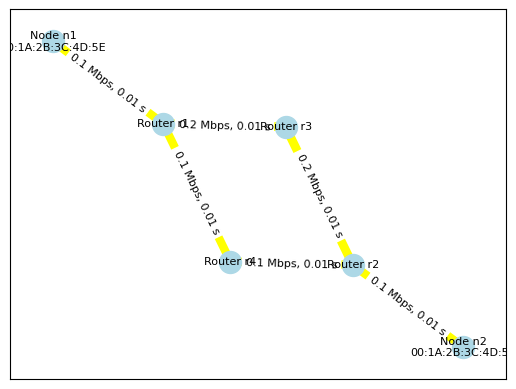

インタフェース情報（ルータ r1）:
  リンク: リンク(n1 ↔ r1, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 192.168.1.254/24
  リンク: リンク(r1 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.3.1/24
  リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.4.1/24
インタフェース情報（ルータ r2）:
  リンク: リンク(r2 ↔ n2, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 192.168.2.254/24
  リンク: リンク(r2 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.3.1/24
  リンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.4.1/24
インタフェース情報（ルータ r3）:
  リンク: リンク(r1 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.3.2/24
  リンク: リンク(r2 ↔ r3, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.3.2/24
インタフェース情報（ルータ r4）:
  リンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.1.4.2/24
  リンク: リンク(r2 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0), IPアドレス: 10.2.4.2/24
0.02968677147046523 Helloパケット受信によるアップデート（ルータ r3）:
  ルータID: r2
    最後のHello受信時刻: 0.02968677147046523
    隣接ルータへのリンク: リンク(r2 ↔ r3, 帯域幅: 

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec6b.NetworkEventScheduler import NetworkEventScheduler
from sec6b.Node import Node
from sec6b.Router import Router
from sec6b.Link import Link

# routing_verbose=Trueでルーティング関連情報を出力
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.1/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.3.1/24", "10.1.4.1/24"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.2.3.1/24", "10.2.4.1/24"], network_event_scheduler=network_event_scheduler)
router3 = Router(node_id="r3", ip_addresses=["10.1.3.2/24", "10.2.3.2/24"], network_event_scheduler=network_event_scheduler)
router4 = Router(node_id="r4", ip_addresses=["10.1.4.2/24", "10.2.4.2/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router2, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router1, router3, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(router1, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(router2, router3, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(router2, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 各ルータのインタフェース情報を確認
router1.print_interfaces()
router2.print_interfaces()
router3.print_interfaces()
router4.print_interfaces()

# イベントスケジューラを実行
network_event_scheduler.run_until(20.0)

# 結果を確認
#network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


## 最短経路の計算

さて、Helloによる隣接関係の構築と、LSAによるトポロジデータベースの構築を経て、いよいよ最短経路の計算を行います。
つまり各ルータは、他のノードに対する最短経路を計算し、それをルーティングテーブルに登録します。
ルートを計算するアルゴリズムを、ルーティングアルゴリズムと呼びます。
ルーティングアルゴリズムにも様々なものがありますが、ここでは最も有名なダイクストラ法を扱います。

### ダイクストラ法とは

ダイクストラ法（Dijkstra's algorithm）は、1959年にエドガー・ダイクストラによって考案されたグラフ理論のアルゴリズムです。
このアルゴリズムは、重み付きグラフ内のある頂点から他の全頂点への最短経路を求めるのに使用されます。
ここでいう「重み」とは、グラフのエッジ（頂点間を結ぶ線）に割り当てられたコストや距離を意味し、最短経路とは、始点から終点までの経路の中で、その重みの合計が最小になる経路のことを指します。

### ダイクストラ法の基本原理

ダイクストラ法は、貪欲法（グリーディアルゴリズム）の一種であり、ステップごとに「最も良い選択」を行うことで、最終的に最適な解を導き出します。
アルゴリズムの各ステップでは、始点からの最短距離が既に確定している頂点集合から、最も距離が短い頂点を選び出し、この頂点を経由することで他の頂点への距離を更新します。手順は以下です。

1. **初期化**: 始点の距離を0とし、他の全頂点の距離を無限大（∞）に設定します。また、各頂点が最短経路上で直前にどの頂点から来たのかを記録するための配列（前駆頂点リスト）を用意します。

2. **距離の更新**: 始点からの最短距離が最も短い頂点を未訪問の頂点集合から選び、この頂点を経由して隣接する頂点への距離を更新します。具体的には、選ばれた頂点を経由した場合の距離が、現在記録されている距離よりも短ければ、その距離を新しい最短距離として更新します。

3. **終了条件**: 未訪問の頂点集合が空になるまで、上記のプロセスを繰り返します。

### アルゴリズムの特徴

- **正の重みに限る**: ダイクストラ法は、グラフの全てのエッジの重みが正である場合にのみ正しく動作します。負の重みが存在する場合、最短経路を正確に求めることができない場合があります。

- **効率性**: ダイクストラ法は、最短経路を求めるアルゴリズムの中では比較的効率的ですが、使用するデータ構造によって性能が大きく変わります。例えば、優先度付きキューを使用すると、計算効率が向上します。

- **応用範囲**: ネットワークルーティング、地図上での経路探索、ソーシャルネットワークでの最短経路問題など、幅広い分野で応用されています。

### `Router`クラスのアップデート

#### 最短経路の計算 (`calculate_shortest_paths`メソッド)
- 初期化: 最初に、ネットワーク内の全ルータに対して最短経路コストを無限大(float('inf'))に設定し、スタートするルータのコストを0に設定します。また、どのルータを経由してそのルータに到達したかを記録するためのprevious_nodes辞書も初期化します。

- プライオリティキューの使用: 最小コストのルータを効率的に探索するために、プライオリティキュー（最小ヒープ）を使用します。キューには、現在のコストとルータIDのタプルが格納されます。

- コストの更新: 現在のルータから到達可能な全ての隣接ルータに対して、そのルータを経由した場合の新しいコストを計算し、これが現在記録されている最短コストよりも小さい場合は、最短経路コストと前駆ルータを更新します。

```
    def calculate_shortest_paths(self, start_router_id):
        # 最短経路コストの辞書を初期化
        shortest_paths = {router_id: float('inf') for router_id in self.topology_database}
        shortest_paths[start_router_id] = 0
        previous_nodes = {router_id: None for router_id in self.topology_database}

        # プライオリティキューを使用して最小コストのルータを探索
        queue = [(0, start_router_id)]
        while queue:
            current_cost, current_router_id = heapq.heappop(queue)

            # 現在のルータから到達可能なルータに対してコストを更新
            if current_router_id in self.topology_database:
                for link, link_info in self.topology_database[current_router_id]['link_state_info'].items():
                    neighbor_router_id = self.get_neighbor_router_id(link, current_router_id)
                    if neighbor_router_id and neighbor_router_id in self.topology_database:
                        new_cost = current_cost + link_info['cost']
                        if new_cost < shortest_paths[neighbor_router_id]:
                            shortest_paths[neighbor_router_id] = new_cost
                            previous_nodes[neighbor_router_id] = current_router_id
                            heapq.heappush(queue, (new_cost, neighbor_router_id))

        return shortest_paths, previous_nodes

    def find_initial_hop(self, destination, previous_nodes, start_router_id):
        current_node = destination
        while current_node is not None:  # Noneでないことを確認
            if previous_nodes.get(current_node) == start_router_id:  # getメソッドを使用してKeyErrorを避ける
                return current_node
            current_node = previous_nodes.get(current_node)  # こちらもgetメソッドを使用

        # start_router_idに到達できなかった場合、エラーメッセージをログに記録または例外を発生
        print(f"Error: No valid path from {start_router_id} to {destination} found.")
        return None  # または適切なエラーハンドリング
```

#### ルーティングテーブルの更新 (`update_routing_table_with_dijkstra`メソッド)
- 最短経路の取得: calculate_shortest_pathsメソッドを呼び出して、スタートルータからネットワーク内の全ルータへの最短経路とコストを取得します。

- ルーティングテーブルの更新: 各目的地に対して、最短経路計算の結果を基にルーティングテーブルを更新します。これには、目的地のCIDR、次のホップルータ、使用するリンクが含まれます。

- 直接接続されたネットワークへのルートの追加: ルータ自身のインターフェースに直接接続されているネットワークへのルートをルーティングテーブルに追加します。これらのルートには、次のホップが不要（None）です。

- ルーティングテーブルの出力: 設定が有効な場合、更新後のルーティングテーブルの内容をコンソールに出力します。これには、各目的地CIDR、次のホップ、使用するリンクが含まれます。

```
    def update_routing_table_with_dijkstra(self):
        shortest_paths, previous_nodes = self.calculate_shortest_paths(self.node_id)

        temp_routing_table = {}

        for destination, _ in shortest_paths.items():
            if destination != self.node_id:
                next_hop = self.find_initial_hop(destination, previous_nodes, self.node_id)
                link_to_next_hop = self.get_link_to_neighbor(next_hop) if next_hop else None
                print(f"From {self.node_id} to {destination}: previous_nodes: {previous_nodes.get(destination)}, next_hop:{next_hop}, link: {link_to_next_hop}")

                # 宛先ルータの全インターフェースに対するルートを個別に算出
                for intf_info in self.topology_database[destination]['link_state_info'].values():
                    destination_cidr = intf_info['ip_address']
                    network = ipaddress.ip_network(destination_cidr, strict=False)
                    network_cidr = str(network)

                    if link_to_next_hop:
                        # 直接接続されたネットワークかどうかを確認
                        directly_connected = any(self.is_same_network(destination_cidr, ip_address) for _, ip_address in self.interfaces.items())
                        if directly_connected:
                        #if previous_nodes.get(destination) == self.node_id:
                            connection_type = "Directly connected"
                        else:
                            connection_type = f"{next_hop}" if next_hop else "Unknown"

                        # 一時的なルーティングテーブルにルートを追加
                        temp_routing_table[network_cidr] = (connection_type, link_to_next_hop)

        # ルータ自身のインターフェースに接続されているネットワークに対するルートを追加
        for link, interface_cidr in self.interfaces.items():
            network = ipaddress.ip_network(interface_cidr, strict=False)
            network_cidr = str(network)
            # 既存のルートがない場合、またはルートがNoneの場合のみ追加
            if network_cidr not in temp_routing_table or temp_routing_table[network_cidr][0] is None:
                temp_routing_table[network_cidr] = ("Directly connected", link)

        # 一時的なルーティングテーブルから最終的なルーティングテーブルへの情報転送
        self.routing_table.clear()
        for destination_cidr, (connection_type, link) in temp_routing_table.items():
            self.routing_table[destination_cidr] = (connection_type, link)

        # ルーティングテーブルの内容を出力
        if self.network_event_scheduler.routing_verbose:
            print(f"Updated Routing Table for Router {self.node_id}:")
            for destination_cidr, (connection_type, link) in self.routing_table.items():
                if "Directly connected" in connection_type:
                    print(f"  Destination: {destination_cidr}, {connection_type}, Link: {link}")
                else:
                    print(f"  Destination: {destination_cidr}, Next hop: {connection_type.replace('via ', '')}, Link: {link}")
```


### ルーティングのテスト

いよいよ、ルーティングアルゴリズムとしてダイクストラ法まで実装した状態で、ルーティングテーブルの生成をテストしてみましょう。
ここでは、結果を確認しやすいように4つのルータを直線状に連結した（daisy chain）トポロジでシミュレーションを実行してみます。
`network_event_scheduler`クラスのインスタンス生成時に、`routing_verbose=True`に設定することで、ルーティング関連情報を出力して確認できます。
`LSA`の受信時にルート計算を行い、ログを出力するように設定されているため、まずは実行して確認してみます。

なお、ノードごとのIPアドレスを一つ一つ記憶していると、ルーティングテーブルに膨大な数のエントリが記載されることになります。
メモリのサイズも大きくなってしまいますし、宛先IPアドレスの検索処理の負荷も非常に大きくなってしまいます。
そのため一般的に、テーブルにはネットワークアドレスを登録します。
例えば`192.168.0.1/24`や`192.168.0.2/24`は、`192.168.0.0/24`として登録されます。
本シミュレータでも、簡易的にこの処理を実装してあるため、ログの形式は以下のようになります。

```
From r1 to r2: previous_nodes: r1, next_hop:r2, link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
From r1 to r4: previous_nodes: r3, next_hop:r2, link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
From r1 to r3: previous_nodes: r2, next_hop:r2, link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
Updated Routing Table for Router r1:
  Destination: 10.1.2.0/24, Directly connected, Link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
  Destination: 10.2.3.0/24, Next hop: r2, Link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
  Destination: 10.3.4.0/24, Next hop: r2, Link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
  Destination: 192.168.2.0/24, Next hop: r2, Link: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
  Destination: 192.168.1.0/24, Directly connected, Link: リンク(n1 ↔ r1, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
```

このログは、ルータr1から他のルータ（r2、r3、r4）へのルーティング情報と、最終的に更新されたルータr1のルーティングテーブルを示しています。

- From r1 to r2:
  - previous_nodes: r1: 宛先r2への最適な経路で、r1の直前のノードはr1自身です。これは、r2がr1に直接接続されていることを意味します。
  - next_hop: r2: 宛先r2へ向かう際の最初のホップ（次に進むべきノード）はr2です。これも、r2が直接接続されていることを示しています。
  - link: 使用されるリンクはr1とr2を直接結ぶリンクです。帯域幅、遅延、パケットロス率の情報も示されています。

- From r1 to r4:
  - previous_nodes: r3: 宛先r4への最適な経路で、r1から見て直前のノードはr3です。
  - next_hop: r2: 宛先r4へ向かう際、r1からは最初にr2へ向かいます。これは、r1からr4への経路がr2を経由することを意味します。
  - link: r1からr4への経路で最初に使用されるリンクは、やはりr1とr2を結ぶリンクです。

- From r1 to r3:
  - previous_nodes: r2: 宛先r3への最適な経路で、r1から見て直前のノードはr2です。
  - next_hop: r2: 宛先r3へ向かう際、r1からは最初にr2へ向かいます。これは、r1からr3への経路がr2を経由することを意味します。
  - link: この経路でも、最初に使用されるリンクはr1とr2を結ぶリンクです。

- 更新されたルーティングテーブル
  - ルータr1のルーティングテーブルには、各宛先ネットワークに対するnext_hopと使用されるlinkの情報が含まれています。
  - 例えば、10.1.2.0/24はDirectly connectedと表示されており、これはr1と直接接続されているネットワークであることを示しています。使用されるリンクはr1とr2を結ぶリンクです。
  - 他の宛先（10.2.3.0/24、10.3.4.0/24、192.168.2.0/24）に対しては、Next hop: r2と表示され、これらの宛先への経路がr2を経由することを示しています。これらの経路でも使用されるリンクはr1とr2を結ぶリンクです。
  - 192.168.1.0/24に関しては、Directly connectedと表示されており、使用されるリンクはn1とr1を結ぶリンクです。これは、このネットワークがr1に直接接続されていることを意味します。


また以下のように、直接ルーティングテーブルや経路を出力して確認することもできます。

```
# ルーティングテーブルの確認
router1.print_routing_table()
router2.print_routing_table()
router3.print_routing_table()
router4.print_routing_table()

# ノードから宛先IPアドレスまでの経路を出力して確認
node1.print_route("192.168.2.1/24")
```


fatal: destination path 'network-simulator' already exists and is not an empty directory.


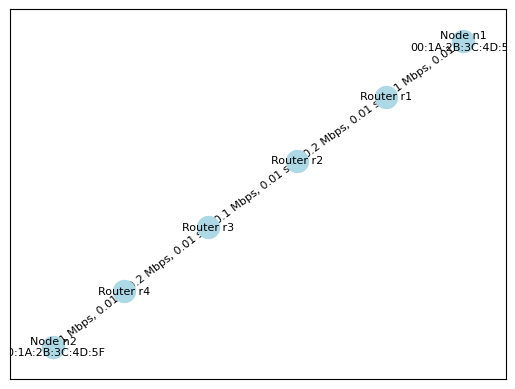

0.022819228980289465 Helloパケット受信によるアップデート（ルータ r3）:
  ルータID: r4
    最後のHello受信時刻: 0.022819228980289465
    隣接ルータへのリンク: リンク(r3 ↔ r4, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r4', 'hello_interval': 10, 'neighbors': []}
0.050450476030066645 Helloパケット受信によるアップデート（ルータ r2）:
  ルータID: r1
    最後のHello受信時刻: 0.050450476030066645
    隣接ルータへのリンク: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r1', 'hello_interval': 10, 'neighbors': []}
0.06595667543955047 Helloパケット受信によるアップデート（ルータ r2）:
  ルータID: r1
    最後のHello受信時刻: 0.050450476030066645
    隣接ルータへのリンク: リンク(r1 ↔ r2, 帯域幅: 200000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r1', 'hello_interval': 10, 'neighbors': []}
  ルータID: r3
    最後のHello受信時刻: 0.06595667543955047
    隣接ルータへのリンク: リンク(r2 ↔ r3, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r3', 'hello_inter

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec6c.NetworkEventScheduler import NetworkEventScheduler
from sec6c.Node import Node
from sec6c.Router import Router
from sec6c.Link import Link

# routing_verbose=Trueでルーティング関連情報を出力
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.1/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.2.1/24"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["10.1.2.2/24", "10.2.3.2/24"], network_event_scheduler=network_event_scheduler)
router3 = Router(node_id="r3", ip_addresses=["10.2.3.3/24", "10.3.4.3/24"], network_event_scheduler=network_event_scheduler)
router4 = Router(node_id="r4", ip_addresses=["192.168.2.254/24", "10.3.4.4/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router1, router2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router2, router3, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(router3, router4, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(router4, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.2.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# イベントスケジューラを実行
network_event_scheduler.run_until(20.0)

# ルーティングテーブルの確認
router1.print_routing_table()
router2.print_routing_table()
router3.print_routing_table()
router4.print_routing_table()

# ノードから宛先IPアドレスまでの経路を出力して確認
node1.print_route("192.168.2.1/24")

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### ルーティングのテスト（別トポロジ）

今度は、ルート分岐があるケースでテストしてみましょう。
今回は以下のように、リンクコストとして`bandwidth`の逆数を用いるように設定してあります。

```
    def calculate_link_cost(self, link):
        # リンクコストを計算する簡単なロジック
        return 1 / link.bandwidth
```

そのため、`bandwidth`から計算されたコストの合計値が低い方のパスが転送経路として選択されます。
以下のコードブロックを実行して、ログから確認してみてください。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


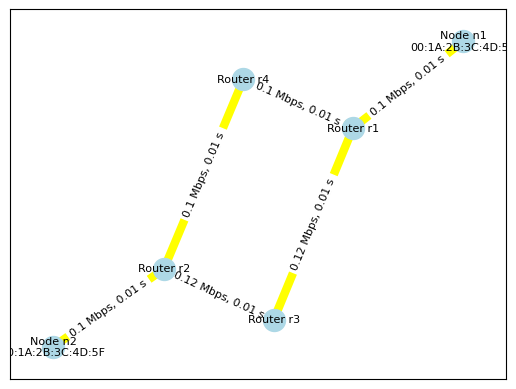

0.06265058663600348 Helloパケット受信によるアップデート（ルータ r3）:
  ルータID: r1
    最後のHello受信時刻: 0.06265058663600348
    隣接ルータへのリンク: リンク(r1 ↔ r3, 帯域幅: 120000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r1', 'hello_interval': 10, 'neighbors': []}
0.06265058663600348 Helloパケット受信によるアップデート（ルータ r4）:
  ルータID: r1
    最後のHello受信時刻: 0.06265058663600348
    隣接ルータへのリンク: リンク(r1 ↔ r4, 帯域幅: 100000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r1', 'hello_interval': 10, 'neighbors': []}
0.06761336016458264 Helloパケット受信によるアップデート（ルータ r1）:
  ルータID: r3
    最後のHello受信時刻: 0.06761336016458264
    隣接ルータへのリンク: リンク(r1 ↔ r3, 帯域幅: 120000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '255.255.255.0', 'router_id': 'r3', 'hello_interval': 10, 'neighbors': []}
0.06761336016458264 Helloパケット受信によるアップデート（ルータ r2）:
  ルータID: r3
    最後のHello受信時刻: 0.06761336016458264
    隣接ルータへのリンク: リンク(r2 ↔ r3, 帯域幅: 120000, 遅延: 0.01, パケットロス率: 0.0)
    追加情報: {'network_mask': '25

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec6c.NetworkEventScheduler import NetworkEventScheduler
from sec6c.Node import Node
from sec6c.Router import Router
from sec6c.Link import Link

# routing_verbose=Trueでルーティング関連情報を出力
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.1/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.3.1/24", "10.1.4.1/24"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.2.3.1/24", "10.2.4.1/24"], network_event_scheduler=network_event_scheduler)
router3 = Router(node_id="r3", ip_addresses=["10.1.3.2/24", "10.2.3.2/24"], network_event_scheduler=network_event_scheduler)
router4 = Router(node_id="r4", ip_addresses=["10.1.4.2/24", "10.2.4.2/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router2, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router1, router3, bandwidth=120000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(router1, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(router2, router3, bandwidth=120000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(router2, router4, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.2.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# イベントスケジューラを実行
network_event_scheduler.run_until(20.0)

# ルーティングテーブルの確認
router1.print_routing_table()
router2.print_routing_table()
router3.print_routing_table()
router4.print_routing_table()

# ノードから宛先IPアドレスまでの経路を出力して確認
node1.print_route("192.168.2.1/24")

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### 演習課題1: 基本的なOSPFルーティングの検証

#### 目的
OSPFルーティングプロトコルを使用して基本的なネットワーク通信を確立し、OSPFの基本動作を理解する。

#### 課題の概要
小規模なネットワークトポロジを用いて、OSPFによる自動ルーティング設定のプロセスを確認します。このシミュレーションでは、2つのルータとそれぞれに接続された2つのノードを設定し、OSPFを使用してルーティングを行います。

#### ステップ
1. **ネットワークトポロジの設定**:
    - ルータ1 (`r1`) とルータ2 (`r2`) を設定します。
    - ノード1 (`n1`) をルータ1に、ノード2 (`n2`) をルータ2に接続します。

2. **IPアドレスの割り当て**:
    - `n1` には `192.168.1.10/24`、`n2` には `192.168.2.10/24` を割り当てます。
    - ルータ間のインターフェイスには `192.168.1.1/24` (r1側) と `192.168.2.1/24` (r2側) を割り当てます。

3. **OSPFの設定**:
    - 両ルータにOSPFを設定し、ノード間での通信が可能になるようにします。

4. **通信のテスト**:
    - `n1` から `n2` へのパケット転送を行い、通信が成功することを確認します。

### 演習課題2: 規模の大きなネットワークでの検証

#### 目的
規模の大きなネットワークで、OSPFルーティングプロトコルを使用したネットワークの基本的な設定と動作を理解し、手動でのルート設定とOSPFによる自動ルート設定の違いを確認する。

#### 課題
5つのルータを任意のトポロジで接続し、OSPFを使用してルーティングテーブルを設定します。
ルータ間でOSPFが正しく動作していることを確認し、ネットワーク内の任意のノード間での通信が可能であることを確認してください。
手計算でのルート設定とOSPFによる自動設定の結果を比較し、OSPFの動作原理について考察してください。

### 演習課題3: リンクコストの変更による経路選択の変化

#### 目的
リンクコストを変更することでOSPFによる経路選択がどのように変化するかを観察し、リンクコストがルーティングに与える影響を理解する。

#### 課題
上記のネットワークトポロジにおいて、リンクの`bandwidth`を変更し、それが経路選択にどのような影響を与えるかを確認してください。リンクコストの変更前後で、通信経路がどのように変化するかを観察し、その理由について考察してください。


## 本章のまとめ

本章では、インターネット上でのパケット転送において必須の機能であるルーティングプロトコルについて学習しました。
代表的なプロトコルであるOSPFの基本的な動作を、簡易的に実装しました。
Helloパケットによる隣接関係の構築と、LSAを用いたトポロジデータベースの構築の手順を作成し、各ルータが同じネットワーク情報を保持することを確認しました。
さらに、よく用いられるダイクストラ法を採用し、ルーティングアルゴリズムによるルート計算も実装しました。
少し実装が複雑になりましたが、シミュレーションを実行してログを順番に確認していくことで、どのようなことが起こっているのかを把握することができます。
次章では、ルータとスイッチを組み合わせ、ネットワークの階層性について学習します。
